In [123]:
! pip install yfinance > /dev/null 2>&1
! mkdir hist
! pip install catboost

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import yfinance as yf
import contextlib
import kagglehub
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score



mkdir: cannot create directory ‘hist’: File exists


In [124]:

# # Download latest version
path_kaggle = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path_kaggle)

Using Colab cache for faster access to the 'stock-market-dataset' dataset.
Path to dataset files: /kaggle/input/stock-market-dataset


In [125]:
offset = 0
limit = 3000
period = 'max'

In [126]:
data = pd.read_csv("http://www.nasdaqtrader.com/dynamic/SymDir/nasdaqtraded.txt", sep='|')
data_clean = data[data['Test Issue'] == 'N']
symbols = data_clean['NASDAQ Symbol'].tolist()
print('total number of symbols traded = {}'.format(len(symbols)))

total number of symbols traded = 12076


The dataset contains stocks and ETFs - we want to specifically look at ETFs

In [127]:
path_kaggle = path_kaggle + '/etfs'
all_etfs = glob.glob(os.path.join(path_kaggle, "*.csv"))
print(all_etfs)

all_etf_symbols_csv = [path[40:] for path in all_etfs]
all_etf_symbols = [csv[:-4] for csv in all_etf_symbols_csv]
print(all_etf_symbols)

# # !Uncomment to view data in each csv
# # Loop through each file and print data
# for file in all_files:
#     df = pd.read_csv(file)
#     print(f"Processing: {file}")
#     # Perform your operations on df here
#     print(df.head())  # Example: print first 5 rows


['/kaggle/input/stock-market-dataset/etfs/LVHE.csv', '/kaggle/input/stock-market-dataset/etfs/HAUZ.csv', '/kaggle/input/stock-market-dataset/etfs/HDIV.csv', '/kaggle/input/stock-market-dataset/etfs/NETL.csv', '/kaggle/input/stock-market-dataset/etfs/HYDB.csv', '/kaggle/input/stock-market-dataset/etfs/XPP.csv', '/kaggle/input/stock-market-dataset/etfs/SPGP.csv', '/kaggle/input/stock-market-dataset/etfs/INTF.csv', '/kaggle/input/stock-market-dataset/etfs/SPBO.csv', '/kaggle/input/stock-market-dataset/etfs/PLW.csv', '/kaggle/input/stock-market-dataset/etfs/XES.csv', '/kaggle/input/stock-market-dataset/etfs/FGM.csv', '/kaggle/input/stock-market-dataset/etfs/TLT.csv', '/kaggle/input/stock-market-dataset/etfs/IYW.csv', '/kaggle/input/stock-market-dataset/etfs/FVC.csv', '/kaggle/input/stock-market-dataset/etfs/CLTL.csv', '/kaggle/input/stock-market-dataset/etfs/BGRN.csv', '/kaggle/input/stock-market-dataset/etfs/GVI.csv', '/kaggle/input/stock-market-dataset/etfs/FXD.csv', '/kaggle/input/stock

## We want the most up to date version of this dataset
> Uncomment the following cell if you want to get the most up to date version of the data


In [128]:
# %%time

# limit = limit if limit else len(symbols)
# end = min(offset + limit, len(symbols))
# is_valid = [False] * len(symbols)
# # force silencing of verbose API
# with open(os.devnull, 'w') as devnull:
#     with contextlib.redirect_stdout(devnull):
#         for i in range(offset, end):
#             s = symbols[i]
#             if s not in all_etf_symbols:
#                 continue
#             try:
#               data = yf.download(s, period=period)
#               if len(data.index) == 0:
#                   continue

#               is_valid[i] = True
#               data.to_csv('hist/{}.csv'.format(s))
#             except:
#               print('Download failed:')
#               is_valid[i] = False

# print('Total number of valid symbols downloaded = {}'.format(sum(is_valid)))

## Find one file with most data, not including columns that are 0
> Uncomment the following cell if you want to run the process of finding which file to use

In [129]:
# max_rows = 0
# max_df = None
# max_file = None

# path_to_downloads = ['/content/hist/'+symbol_csv for symbol_csv in all_etf_symbols_csv]

# for file in path_to_downloads:
#   if os.path.exists(file):
#     df = pd.read_csv(file)
#     df = df[df['Open'] != 0] #remove lines where open == 0
#     # df = df.drop(columns=['Date']) #drops the date column completely, will deal with this later
#     if len(df) > max_rows:
#       max_rows = len(df)
#       max_df = df
#       max_file = file
# print("Data Frame: \n" , max_df.head(), "\nRows: " , max_rows, "\nFile: " , max_file)



> Results: File:  /content/hist/CEF.csv




## Download and read in the dataset


In [130]:
with open(os.devnull, 'w') as devnull:
    with contextlib.redirect_stdout(devnull):
      s = 'CEF'
      try:
        data = yf.download(s, period=period)

        data.to_csv('hist/{}.csv'.format(s))
      except:
        print('Download failed:')

df = pd.read_csv('/content/hist/CEF.csv')


/tmp/ipython-input-3027740980.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(s, period=period)
[*********************100%***********************]  1 of 1 completed


In [131]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,CEF,CEF,CEF,CEF,CEF
1,Date,NaN,NaN,NaN,NaN,NaN
2,1986-04-03,4.449551105499268,4.569809243485734,4.449551105499268,4.449551105499268,15300
3,1986-04-04,4.569810390472412,4.569810390472412,4.509681306387249,4.509681306387249,12000
4,1986-04-07,4.569810390472412,4.690068558642739,4.569810390472412,4.569810390472412,11500


## Clean data to correctly format



In [132]:
# convert prices to % returns to see how much price changed from yesterday

# Correcting the DataFrame structure first due to incorrect read_csv parsing.
# Based on the df.head() output, the actual data starts from the third row (index 2).
# The first column contains the Date, which should be the index.
df = df.iloc[2:].copy()

# Rename the first column to 'Date' and set it as the index
df.rename(columns={'Price': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Convert relevant columns to numeric, coercing errors will turn non-convertible values into NaN
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that might have become entirely NaN after coercion or were bad data
df.dropna(inplace=True)


## Include price changes as columns

In [133]:
df['Open_Pct']   = df['Open'].pct_change()
df['High_Pct']   = df['High'].pct_change()
df['Low_Pct']    = df['Low'].pct_change()
df['Close_Pct']  = df['Close'].pct_change()
df['Volume_Pct'] = df['Volume'].pct_change()

In [152]:
df.head()
# print(df.index.to_list())

,Close,High,Low,Open,Volume,Open_Pct,High_Pct,Low_Pct,Close_Pct,Volume_Pct,Prev_Close_Pct,Prev_Volume_Pct,Prev_High_Low_Range,MA_5,MA_20,Price_to_MA5,Price_to_MA20,Volatility_5,Volatility_20,Target
Date,,,,,,,,,,,,,,,,,,,,
1986-05-30,4.209036,4.269165,4.209036,4.269165,11700,1.428581e-02,9.254589e-08,9.254589e-08,-0.014084,0.114286,-0.014084,0.114286,0.014286,4.233087,4.245113,0.994318,0.991501,0.011856,0.014752,0.000000
1986-06-02,4.209036,4.269165,4.209036,4.209036,8800,-1.408451e-02,0.000000e+00,0.000000e+00,0.000000,-0.247863,0.000000,-0.247863,0.014286,4.221062,4.239100,0.997151,0.992908,0.011856,0.014496,-0.014286
1986-06-03,4.148907,4.269165,4.148907,4.209036,9900,-1.970242e-08,-1.970242e-08,-1.428573e-02,-0.014286,0.125000,-0.014286,0.125000,0.028986,4.209036,4.230081,0.985714,0.980810,0.011904,0.014777,0.000000
1986-06-04,4.148907,4.148907,4.148907,4.148907,1100,-1.428571e-02,-2.816901e-02,0.000000e+00,0.000000,-0.888889,0.000000,-0.888889,0.000000,4.197010,4.221062,0.988539,0.982906,0.011904,0.014777,0.000000
1986-06-05,4.148907,4.209036,4.148907,4.148907,6000,0.000000e+00,1.449275e-02,0.000000e+00,0.000000,4.454545,0.000000,4.454545,0.014493,4.172958,4.218055,0.994236,0.983607,0.007770,0.013477,0.014493


# Catboost 1
>There are conceptual issues with this model. It has these fatal flaws:
*   Wrong timing: it is using today's close to predict tomorrow, but can't trade after close
*   Data leakage: shuffle=True means your model sees the future during training
*   Future information: it is using High/Low/Close from the same day - data you won't have when making decisions



In [135]:

# # predict next day's close return by shifting column up by 1
# # this means: use today's data (row i) to predict tomorrow's return (row i+1)
# df['Target_Next_Day_Return'] = df['Close_Pct'].shift(-1)
# df = df.dropna() # remove bad columns

# # 5. Define X and y using the NEW features
# features = ['Open_Pct', 'High_Pct', 'Low_Pct', 'Close_Pct', 'Volume_Pct']
# X = df[features]
# y = df['Target_Next_Day_Return']

# #this splits the data for train and test
# #shuffle = false make its chronological where train is older than test
# #shuffle = true makes it random
# #not sure which to choose since having it random leads to data leakage / memorization between open and closes between days
# #but leaving it chronological means if the stock goes up and the train data was never tested with numbers that high itll max out and have a really bad r2 score
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True)

# print("starting best parameter search")

# param_grid = {
#     'depth': [4, 6, 8, 10],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'l2_leaf_reg': [1, 3, 5]
# }

# base_model = CatBoostRegressor(
#     iterations = 500,
#     loss_function = 'RMSE',
#     random_seed = 96594,
#     verbose = 0,
#     allow_writing_files = False
# )

# grid_search = GridSearchCV(
#     estimator = base_model,
#     param_grid = param_grid,
#     #cv = TimeSeriesSplit(n_splits=3), #chronological splits
#     cv = 3, #random splits
#     scoring = 'r2',
#     n_jobs = -1
# )

# grid_search.fit(X_train, y_train)

# print(f"best r2 score: {grid_search.best_score_:.4f}")
# print("best parameters found:", grid_search.best_params_)

# best_model = grid_search.best_estimator_

# importance = best_model.get_feature_importance()
# feature_names = X_train.columns
# importance_df = pd.DataFrame({'feature': feature_names, 'score': importance})

# importance_df = importance_df.sort_values(by='score', ascending=False)
# print(importance_df)

# low_impact_features = importance_df[importance_df['score'] < 5.0]['feature'].tolist()
# important_features = importance_df[importance_df['score'] >= 5.0]['feature'].tolist()
# print(f"dropping {len(low_impact_features)} features: {low_impact_features}")

# X_train_reduced = X_train.drop(columns=low_impact_features)
# X_test_reduced = X_test.drop(columns=low_impact_features)

In [136]:

# print("training best model on full reduced dataset")
# best_model.fit(X_train_reduced, y_train)
# y_pred = best_model.predict(X_test_reduced)

# score = r2_score(y_test, y_pred)
# print("test R2 Score:", score)

training best model on full reduced dataset
test R2 Score: 0.016726967389407377


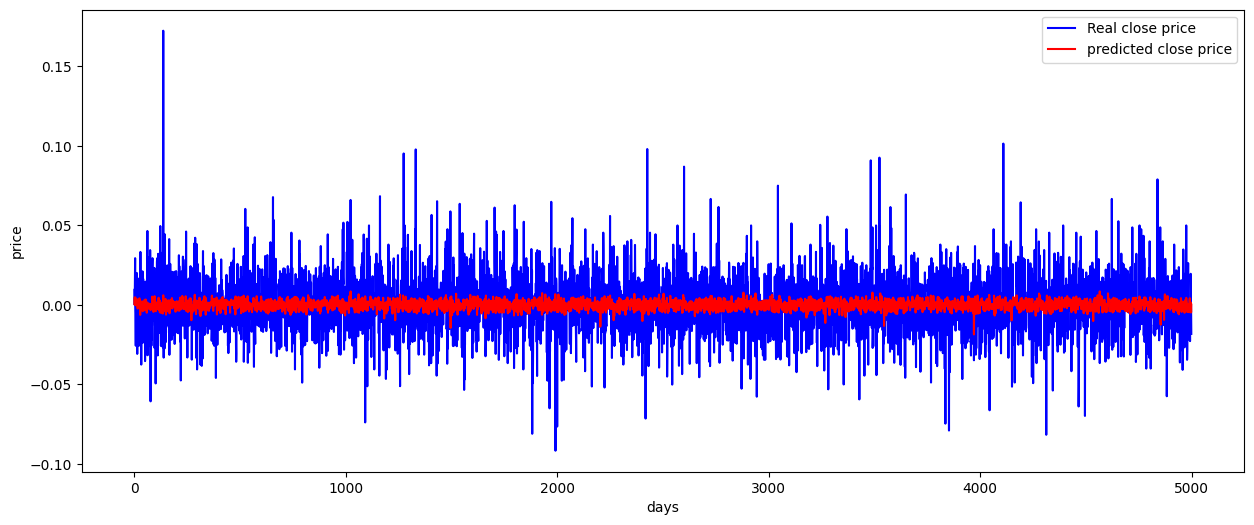

In [137]:

# #plots y_pred vs y_test
# plt.figure(figsize=(15, 6))
# plt.plot(y_test.values, label='Real close price', color='blue')
# plt.plot(y_pred, label='predicted close price', color='red')
# plt.xlabel("days")
# plt.ylabel("price")
# plt.legend()
# # plt.xticks(df.index.to_list())
# plt.show()

In [138]:
# def predict_with_new_data(model, features, open_pct, high_pct, low_pct, close_pct, volume_pct):
#     """
#     Predict tomorrow's return given today's percentage changes

#     Parameters:
#     - open_pct, high_pct, low_pct, close_pct, volume_pct: Today's percentage changes

#     Returns:
#     - predicted_return: Tomorrow's predicted close return
#     """
#     # Create input dataframe with exact feature names
#     input_data = pd.DataFrame({
#         'Open_Pct': [open_pct],
#         'High_Pct': [high_pct],
#         'Low_Pct': [low_pct],
#         'Close_Pct': [close_pct],
#         'Volume_Pct': [volume_pct]
#     })

#     # Only use features that weren't dropped due to low importance
#     input_data = input_data[features]

#     predicted_return = model.predict(input_data)[0]

#     return predicted_return

In [139]:
# pred = predict_with_new_data(
#     model=best_model,
#     features=important_features,
#     open_pct=0.00117564,    # Open was % higher than yesterday's close
#     high_pct=0.012,    # High was 1.2% higher
#     low_pct=-0.003,    # Low was 0.3% lower
#     close_pct=0.008,   # Close was 0.8% higher
#     volume_pct=0.15    # Volume was 15% higher
# )
# print(f"Manual prediction: {pred:.4f} ({pred*100:.2f}%)")

NameError: name 'important_features' is not defined

# Catboost 2

In [144]:
from sklearn.model_selection import TimeSeriesSplit

# Create features using ONLY previous day's data
df['Prev_Close_Pct'] = df['Close'].pct_change()
df['Prev_Volume_Pct'] = df['Volume'].pct_change()
df['Prev_High_Low_Range'] = (df['High'] - df['Low']) / df['Low']

# Moving averages
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['Price_to_MA5'] = df['Close'] / df['MA_5']
df['Price_to_MA20'] = df['Close'] / df['MA_20']

# Volatility
df['Volatility_5'] = df['Close'].pct_change().rolling(5).std()
df['Volatility_20'] = df['Close'].pct_change().rolling(20).std()

# Target: Tomorrow's open-to-close return
df['Target'] = ((df['Close'] - df['Open']) / df['Open']).shift(-1)

df = df.dropna()

# Features available BEFORE tomorrow opens
features = [
    'Prev_Close_Pct', 'Prev_Volume_Pct', 'Prev_High_Low_Range',
    'Price_to_MA5', 'Price_to_MA20', 'Volatility_5', 'Volatility_20'
]

X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y)


# CRITICAL: Use TimeSeriesSplit for proper validation
tscv = TimeSeriesSplit(n_splits=5)

base_model = CatBoostRegressor(
    iterations=500,
    loss_function='RMSE',
    random_seed=96594,
    verbose=0
)

base_model.fit(X_train, y_train)

In [153]:
y_pred = base_model.predict(X_test)
score = r2_score(y_test, y_pred)
print("test R2 Score:", score)

test R2 Score: -0.05221872709964415


In [149]:
def should_invest_tomorrow(today_data, model, features):
    """
    Decide if you should buy at tomorrow's open

    Returns:
    - prediction: Expected return from open to close tomorrow
    - decision: 'BUY' if prediction > threshold, else 'HOLD'
    """
    X_today = today_data[features].iloc[-1:]
    predicted_return = model.predict(X_today)[0]

    # Only invest if predicted return > transaction costs + buffer
    threshold = 0.005  # 0.5% (covers fees + requires meaningful gain)

    decision = 'BUY' if predicted_return > threshold else 'HOLD'

    return predicted_return, decision



In [154]:
# optimize with grid search
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5]
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,  # Use time series split
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [155]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = r2_score(y_test, y_pred)
print("test R2 Score:", score)

test R2 Score: 0.014965823476209228


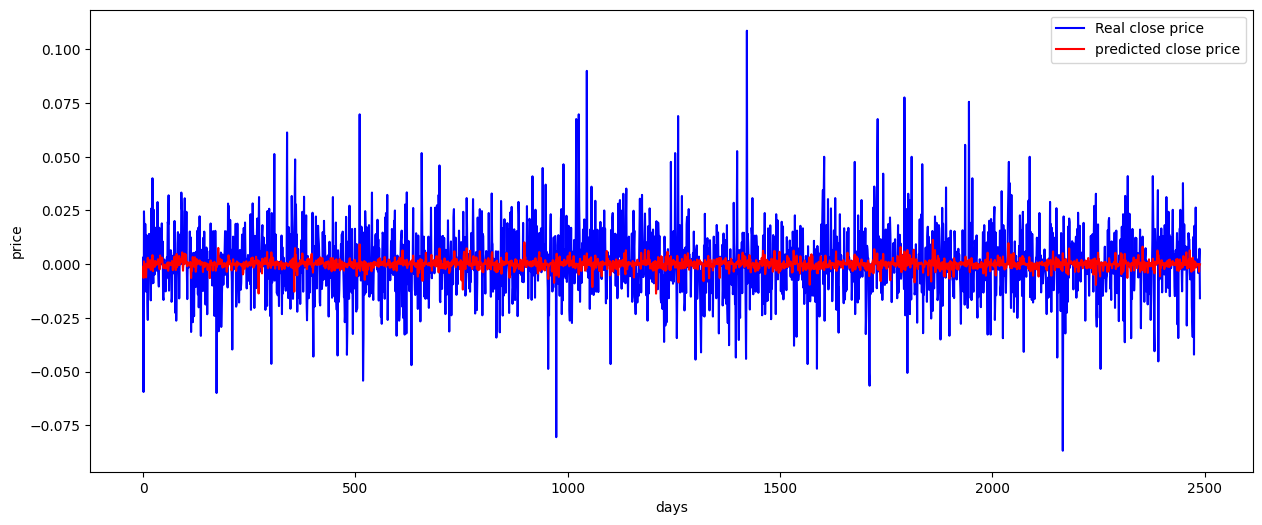

In [157]:
#plots y_pred vs y_test
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Real close price', color='blue')
plt.plot(y_pred, label='predicted close price', color='red')
plt.xlabel("days")
plt.ylabel("price")
plt.legend()
# plt.xticks(df.index.to_list())
plt.show()

#Predicting on day of 12/10/25

### Base model prediction

In [150]:
# Example usage
predicted_return, decision = should_invest_tomorrow(df, base_model, features)
print(f"Predicted tomorrow's return: {predicted_return}")
print(f"Therefore you should {decision}")

Predicted tomorrow's return: 0.004245345032295634
Therefore you should HOLD


### Best model prediction

In [156]:
predicted_return, decision = should_invest_tomorrow(df, best_model, features)
print(f"Predicted tomorrow's return: {predicted_return}")
print(f"Therefore you should {decision}")

Predicted tomorrow's return: 0.0004350529293696906
Therefore you should HOLD
